# Evaluación Formativa 2 — Práctica de Modelamiento Predictivo
## Predicción de lluvia del día siguiente en Australia

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial
**Universidad Andrés Bello**

## Información del Equipo

| Campo | Información |
|---|---|
| **Grupo** | Grupo 2 |
| **Integrante 1** | Enzo Pinilla |
| **Integrante 2** | Claudio Alarcón |
| **Integrante 3** | Luis Rodrigo Espinoza |
| **Dataset seleccionado** | WeatherAUS / Rain in Australia (Kaggle) |
| **Docente** | Dr. Jean Paul Maidana González |
| **Fecha** | 10 de julio de 2026 |
| **Repositorio** | https://github.com/sauriomac/mcdi501-estadistica-computacional-grupo2 |

## Propósito de esta Formativa

Esta evaluación permite practicar el flujo completo de modelamiento predictivo antes de la
Sumativa 3, y recibir retroalimentación temprana.

**Qué se hace aquí:** un solo modelo de regresión logística, con una estrategia simple de datos
faltantes (mediana/moda), sobre las variables ya validadas en S1 y S2.

**Diferencia con S3:** en la Sumativa 3 se construirán **tres** modelos con criterios de
selección distintos (dominio S1/S2, *stepwise* por AIC/BIC y un modelo reducido), se reemplazará
la imputación simple por **imputación por regresión**, se aplicará **bootstrap** a los
coeficientes del mejor modelo para obtener intervalos de confianza de sus odds ratios, y se
ampliará el diagnóstico con la distancia de Cook. Esta formativa es, deliberadamente, la versión
simplificada de ese flujo.

In [4]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report, roc_curve, roc_auc_score,
    average_precision_score,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "font.size": 10})

print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


## 1. Preparación de datos

### 1.1 Carga del dataset

Se reutiliza el mismo conjunto empleado en S1 y S2. Antes del modelamiento se eliminan únicamente
los registros sin variable objetivo, porque no pueden participar en un problema supervisado.

In [5]:
from pathlib import Path
import pandas as pd

# Mostrar desde dónde está ejecutándose el notebook
print("Directorio actual:", Path.cwd())

candidate_paths = [
    Path.cwd() / "data" / "raw" / "weatherAUS.csv",
    Path.cwd().parent / "data" / "raw" / "weatherAUS.csv",
    Path.cwd().parent.parent / "data" / "raw" / "weatherAUS.csv",
    Path.cwd() / "weatherAUS.csv",
]

print("\nRutas revisadas:")
for ruta in candidate_paths:
    print(f"{ruta} -> {ruta.exists()}")

DATA_PATH = next(
    (ruta for ruta in candidate_paths if ruta.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró weatherAUS.csv en las rutas revisadas."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"\nFuente utilizada: {DATA_PATH}")
print(
    f"Dimensiones cargadas: "
    f"{df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas"
)

display(df_raw.head())

Directorio actual: c:\Users\01\OneDrive\Documentos\estadistica\mcdi501-estadistica-computacional-grupo2\notebooks

Rutas revisadas:
c:\Users\01\OneDrive\Documentos\estadistica\mcdi501-estadistica-computacional-grupo2\notebooks\data\raw\weatherAUS.csv -> False
c:\Users\01\OneDrive\Documentos\estadistica\mcdi501-estadistica-computacional-grupo2\data\raw\weatherAUS.csv -> True
c:\Users\01\OneDrive\Documentos\estadistica\data\raw\weatherAUS.csv -> False
c:\Users\01\OneDrive\Documentos\estadistica\mcdi501-estadistica-computacional-grupo2\notebooks\weatherAUS.csv -> False

Fuente utilizada: c:\Users\01\OneDrive\Documentos\estadistica\mcdi501-estadistica-computacional-grupo2\data\raw\weatherAUS.csv
Dimensiones cargadas: 145,460 filas × 23 columnas


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4000,22.9000,0.6000,NaN,NaN,W,44.0000,W,WNW,20.0000,24.0000,71.0000,22.0000,"1,007.7000","1,007.1000",8.0000,NaN,16.9000,21.8000,No,No
1,2008-12-02,Albury,7.4000,25.1000,0.0000,NaN,NaN,WNW,44.0000,NNW,WSW,4.0000,22.0000,44.0000,25.0000,"1,010.6000","1,007.8000",NaN,NaN,17.2000,24.3000,No,No
2,2008-12-03,Albury,12.9000,25.7000,0.0000,NaN,NaN,WSW,46.0000,W,WSW,19.0000,26.0000,38.0000,30.0000,"1,007.6000","1,008.7000",NaN,2.0000,21.0000,23.2000,No,No
3,2008-12-04,Albury,9.2000,28.0000,0.0000,NaN,NaN,NE,24.0000,SE,E,11.0000,9.0000,45.0000,16.0000,"1,017.6000","1,012.8000",NaN,NaN,18.1000,26.5000,No,No
4,2008-12-05,Albury,17.5000,32.3000,1.0000,NaN,NaN,W,41.0000,ENE,NW,7.0000,20.0000,82.0000,33.0000,"1,010.8000","1,006.0000",7.0000,8.0000,17.8000,29.7000,No,No


In [6]:
TARGET = "RainTomorrow"
valid_target_mask = df_raw[TARGET].isin(["Yes", "No"])
df = df_raw.loc[valid_target_mask].copy()
df["RainTomorrow_bin"] = df[TARGET].map({"No": 0, "Yes": 1}).astype(int)

n_target_missing = len(df_raw) - len(df)
print(f"Registros sin objetivo excluidos: {n_target_missing:,}")
print(f"Muestra válida para modelamiento: {len(df):,} filas")
print("Distribución del objetivo:")
display(
    df["RainTomorrow_bin"]
      .value_counts()
      .sort_index()
      .rename(index={0: "No", 1: "Yes"})
      .to_frame("frecuencia")
      .assign(porcentaje=lambda t: 100 * t["frecuencia"] / t["frecuencia"].sum())
)

Registros sin objetivo excluidos: 3,267
Muestra válida para modelamiento: 142,193 filas
Distribución del objetivo:


,frecuencia,porcentaje
RainTomorrow_bin,,
No,110316,77.5819
Yes,31877,22.4181


### 1.2 Hallazgos heredados de S1

S1 estableció el diagnóstico exploratorio e inferencial que condiciona este modelo. Se recalculan
aquí las correlaciones sobre el mismo dataset, para dejar trazabilidad exacta con S1.

In [7]:
num_vars_s1 = ["MinTemp","MaxTemp","Rainfall","Humidity9am","Humidity3pm",
               "Pressure9am","Temp9am","Temp3pm","WindGustSpeed"]
df["RainToday_bin_tmp"] = df["RainToday"].map({"No": 0, "Yes": 1})
corr_target_s1 = (
    df[num_vars_s1 + ["RainTomorrow_bin", "RainToday_bin_tmp"]]
    .corr(numeric_only=True)["RainTomorrow_bin"]
    .drop(labels=["RainTomorrow_bin"])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("correlación_con_RainTomorrow")
    .to_frame()
)
display(corr_target_s1.round(3))

print("Colinealidad detectada en S1: corr(MaxTemp, Temp3pm) =",
      round(df[["MaxTemp", "Temp3pm"]].corr().iloc[0, 1], 3))

,correlación_con_RainTomorrow
Humidity3pm,0.4460
RainToday_bin_tmp,0.3130
Humidity9am,0.2570
Pressure9am,-0.2460
Rainfall,0.2390
WindGustSpeed,0.2340
Temp3pm,-0.1920
MaxTemp,-0.1590
MinTemp,0.0840
Temp9am,-0.0260


Colinealidad detectada en S1: corr(MaxTemp, Temp3pm) = 0.985


**Resumen narrativo de S1:**
- **Variable objetivo:** `RainTomorrow` (1 = llueve al día siguiente), con desbalance moderado
  (≈22.4% de casos positivos).
- **Variables más correlacionadas:** `Humidity3pm` (r≈0.45) es el predictor más fuerte, seguido de
  `RainToday`, `Humidity9am`, `Pressure9am` (correlación negativa) y `Rainfall`.
- **Problemas identificados:** colinealidad casi perfecta entre `MaxTemp` y `Temp3pm` (r≈0.985);
  faltantes muy altos en `Sunshine` (≈48%) y `Evaporation` (≈43%); asimetría y curtosis extremas
  en `Rainfall` y `WindGustSpeed`.

### 1.3 Hallazgos heredados de S2

S2 validó mediante bootstrap BCa (10.000 remuestras) que las asociaciones de `Humidity3pm`,
`RainToday_bin`, `Humidity9am`, `Pressure9am` y `Rainfall` conservan su signo y sus intervalos no
incluyen cero. También mostró que la regla IQR marca cerca de 18% de `Rainfall` como "atípico"
solo por la concentración de ceros, por lo que en vez de recortar valores se usa
`log1p(Rainfall)`.

In [8]:
correlaciones_s2 = pd.DataFrame([
    ["Humidity3pm",   0.4462,  0.4418,  0.4505, "Estable"],
    ["RainToday_bin", 0.3131,  0.3074,  0.3189, "Estable"],
    ["Humidity9am",   0.2572,  0.2526,  0.2616, "Estable"],
    ["Pressure9am",  -0.2464, -0.2516, -0.2411, "Estable"],
    ["Rainfall",      0.2390,  0.2319,  0.2462, "Estable"],
], columns=["Variable", "r observado", "IC95 inferior", "IC95 superior", "Conclusión"])
display(correlaciones_s2)

parametros_robustos_s2 = pd.DataFrame([
    ["Media Humidity3pm",          51.5391, "IC clásico ~ IC bootstrap"],
    ["Media WindGustSpeed",        40.0352, "Estable, con sensibilidad moderada a extremos"],
    ["Media Rainfall",              2.3609, "Requiere cautela por cero-inflación y cola pesada"],
    ["Proporción RainTomorrow=Yes", 0.2242, "Wilson ~ bootstrap; confirma desbalance"],
], columns=["Parámetro", "Estimación S2", "Lectura"])
display(parametros_robustos_s2)

,Variable,r observado,IC95 inferior,IC95 superior,Conclusión
0,Humidity3pm,0.4462,0.4418,0.4505,Estable
1,RainToday_bin,0.3131,0.3074,0.3189,Estable
2,Humidity9am,0.2572,0.2526,0.2616,Estable
3,Pressure9am,-0.2464,-0.2516,-0.2411,Estable
4,Rainfall,0.2390,0.2319,0.2462,Estable


,Parámetro,Estimación S2,Lectura
0,Media Humidity3pm,51.5391,IC clásico ~ IC bootstrap
1,Media WindGustSpeed,40.0352,"Estable, con sensibilidad moderada a extremos"
2,Media Rainfall,2.3609,Requiere cautela por cero-inflación y cola pesada
3,Proporción RainTomorrow=Yes,0.2242,Wilson ~ bootstrap; confirma desbalance


**Resumen narrativo de S2:**
- **Correlaciones estables:** `Humidity3pm`, `RainToday_bin`, `Humidity9am`, `Pressure9am` y
  `Rainfall` mantuvieron su signo y magnitud entre remuestras bootstrap (IC del 95% sin cruzar 0).
  Son predictores confiables.
- **Robustez frente a outliers:** la regla IQR degenera en `Rainfall` por la concentración de
  ceros (no se recorta, se transforma con `log1p`); los extremos de `WindGustSpeed` se interpretan
  como ráfagas reales y tampoco se recortan.

### 1.4 Selección de variables y tratamiento

Se seleccionan cinco predictores, todos con correlación estable confirmada en S2:

- **Humidity3pm:** asociación estable más alta.
- **RainToday_bin:** correlación estable y señal meteorológica inmediatamente anterior.
- **Pressure9am:** asociación estable negativa (factor protector).
- **Rainfall_log1p:** correlación estable, transformada por su cola pesada y concentración de
  ceros (hallazgo de robustez de S2).
- **WindGustSpeed:** asociación relevante en S1 y parámetro validado en S2; agrega una dimensión
  física distinta de humedad, presión y lluvia.

`Humidity9am` se reserva: aunque su correlación marginal es estable, se limita el modelo a cinco
variables y se evita duplicar en exceso información de humedad ya representada por
`Humidity3pm`. `MaxTemp`/`Temp3pm` se excluyen por su colinealidad casi perfecta (S1).

In [9]:
df["RainToday_bin"] = df["RainToday_bin_tmp"]
df = df.drop(columns=["RainToday_bin_tmp"])

if (df["Rainfall"].dropna() < 0).any():
    raise ValueError("Rainfall contiene valores negativos; se requiere revisar el dominio.")
df["Rainfall_log1p"] = np.log1p(df["Rainfall"])

FEATURES = ["Humidity3pm", "RainToday_bin", "Pressure9am", "Rainfall_log1p", "WindGustSpeed"]
CONTINUOUS_FEATURES = ["Humidity3pm", "Pressure9am", "Rainfall_log1p", "WindGustSpeed"]
BINARY_FEATURES = ["RainToday_bin"]

missing_report = pd.DataFrame({
    "faltantes": df[FEATURES].isna().sum(),
    "% faltantes": 100 * df[FEATURES].isna().mean(),
    "mecanismo (hipótesis)": ["MAR: más faltante donde faltan otras lecturas de la tarde",
                               "MCAR: reporte binario, sin patrón evidente",
                               "MAR: instrumentos matutinos con mantenimiento agrupado por estación",
                               "MCAR: asociado al mismo registro diario de lluvia",
                               "MAR: sensor de ráfaga con vacíos agrupados por estación"],
}, index=FEATURES).sort_values("% faltantes", ascending=False)
display(missing_report)

,faltantes,% faltantes,mecanismo (hipótesis)
Pressure9am,14014,9.8556,MAR: instrumentos matutinos con mantenimiento ...
WindGustSpeed,9270,6.5193,MAR: sensor de ráfaga con vacíos agrupados por...
Humidity3pm,3610,2.5388,MAR: más faltante donde faltan otras lecturas ...
RainToday_bin,1406,0.9888,"MCAR: reporte binario, sin patrón evidente"
Rainfall_log1p,1406,0.9888,MCAR: asociado al mismo registro diario de lluvia


**Justificación de la estrategia elegida:** imputación por **mediana** para los predictores
continuos (robusta frente a la asimetría de `Rainfall_log1p` y `WindGustSpeed`) y por **moda**
para `RainToday_bin`. Es una estrategia simple, apropiada para esta formativa: preserva el tamaño
completo de la muestra, a diferencia de eliminar los casos incompletos, aunque como limitación
conocida comprime artificialmente la varianza de las variables imputadas. Los parámetros de
imputación se estiman únicamente en entrenamiento, para no filtrar información hacia prueba.

> **Para S3:** se comparará esta estrategia simple contra la eliminación de casos y la imputación
> por regresión lineal, evaluando su efecto sobre el tamaño muestral y los coeficientes del
> modelo.

### 1.5 Partición 70/30 y preprocesamiento sin fuga

In [10]:
X = df[FEATURES].copy()
y = df["RainTomorrow_bin"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y,
)

continuous_imputer = SimpleImputer(strategy="median")
binary_imputer = SimpleImputer(strategy="most_frequent")
scaler = StandardScaler()

X_train_cont_imp = continuous_imputer.fit_transform(X_train[CONTINUOUS_FEATURES])
X_test_cont_imp = continuous_imputer.transform(X_test[CONTINUOUS_FEATURES])

X_train_processed = pd.DataFrame(
    scaler.fit_transform(X_train_cont_imp), columns=CONTINUOUS_FEATURES, index=X_train.index,
)
X_test_processed = pd.DataFrame(
    scaler.transform(X_test_cont_imp), columns=CONTINUOUS_FEATURES, index=X_test.index,
)
X_train_processed["RainToday_bin"] = binary_imputer.fit_transform(X_train[["RainToday_bin"]]).ravel()
X_test_processed["RainToday_bin"] = binary_imputer.transform(X_test[["RainToday_bin"]]).ravel()

X_train_processed = X_train_processed[FEATURES].astype(float)
X_test_processed = X_test_processed[FEATURES].astype(float)

print(f"Entrenamiento: {len(X_train):,} observaciones ({len(X_train)/len(X):.1%})")
print(f"Prueba:        {len(X_test):,} observaciones ({len(X_test)/len(X):.1%})")
print(f"Proporción positiva en train: {y_train.mean():.4f}")
print(f"Proporción positiva en test:  {y_test.mean():.4f}")

assert X_train_processed.isna().sum().sum() == 0
assert X_test_processed.isna().sum().sum() == 0
assert abs(y_train.mean() - y_test.mean()) < 0.001
print("Controles superados: sin faltantes luego del procesamiento y estratificación conservada.")

Entrenamiento: 99,535 observaciones (70.0%)
Prueba:        42,658 observaciones (30.0%)
Proporción positiva en train: 0.2242
Proporción positiva en test:  0.2242
Controles superados: sin faltantes luego del procesamiento y estratificación conservada.


### Distribución de predictores por clase

Antes de ajustar el modelo, conviene ver por qué las dos variables más fuertes separan bien las
clases.

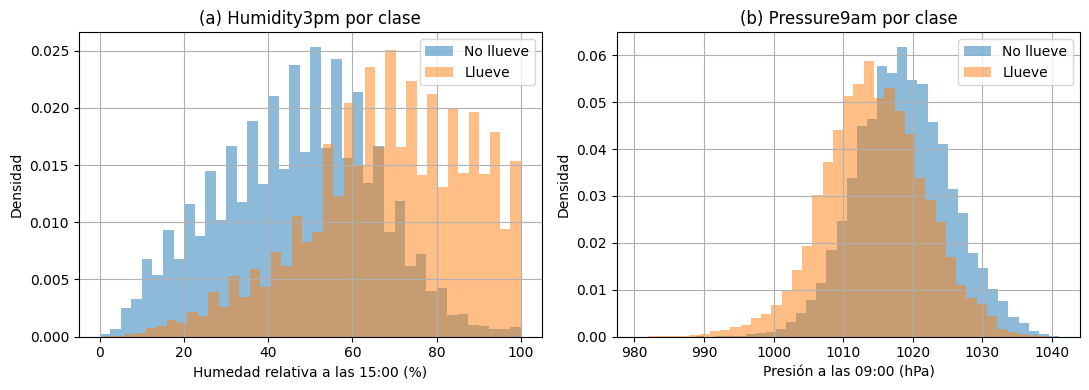

Los días con lluvia al día siguiente concentran una humedad de tarde notablemente más alta (a), mientras que la presión matinal muestra el patrón inverso y anticipa su rol protector (b).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for clase, label in [(0, "No llueve"), (1, "Llueve")]:
    subset = df[df["RainTomorrow_bin"] == clase]
    axes[0].hist(subset["Humidity3pm"].dropna(), bins=40, density=True, alpha=0.5, label=label)
    axes[1].hist(subset["Pressure9am"].dropna(), bins=40, density=True, alpha=0.5, label=label)

axes[0].set_title("(a) Humidity3pm por clase")
axes[0].set_xlabel("Humedad relativa a las 15:00 (%)"); axes[0].set_ylabel("Densidad")
axes[0].legend()
axes[1].set_title("(b) Pressure9am por clase")
axes[1].set_xlabel("Presión a las 09:00 (hPa)"); axes[1].set_ylabel("Densidad")
axes[1].legend()
plt.tight_layout()
plt.savefig("f2_dist_por_clase.png", dpi=160, bbox_inches="tight")
plt.show()

print("Los días con lluvia al día siguiente concentran una humedad de tarde notablemente más "
      "alta (a), mientras que la presión matinal muestra el patrón inverso y anticipa su rol "
      "protector (b).")

## 2. Modelo de regresión logística

### 2.1 Ajuste

Se utiliza `statsmodels.Logit` para obtener el resumen inferencial completo. Los predictores
continuos están estandarizados, por lo que sus odds ratios representan el cambio multiplicativo en
las odds de lluvia ante un aumento de una desviación estándar.

In [12]:
X_train_sm = sm.add_constant(X_train_processed, has_constant="add")
logit_model = sm.Logit(y_train, X_train_sm).fit(disp=0, maxiter=200)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:       RainTomorrow_bin   No. Observations:                99535
Model:                          Logit   Df Residuals:                    99529
Method:                           MLE   Df Model:                            5
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.2793
Time:                        23:17:07   Log-Likelihood:                -38176.
converged:                       True   LL-Null:                       -52968.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.7666      0.014   -124.210      0.000      -1.794      -1.739
Humidity3pm        1.2510      0.012    107.892      0.000       1.228       1.274
RainToday_bin      0.1204      0.039

### 2.2 Coeficientes, odds ratios y significancia

In [13]:
conf_int = logit_model.conf_int()
coef_table = pd.DataFrame({
    "coeficiente": logit_model.params,
    "error_estandar": logit_model.bse,
    "z": logit_model.tvalues,
    "p_valor": logit_model.pvalues,
    "odds_ratio": np.exp(logit_model.params),
    "OR_IC95_inf": np.exp(conf_int[0]),
    "OR_IC95_sup": np.exp(conf_int[1]),
})
coef_table["significativo_5pct"] = coef_table["p_valor"] < 0.05
display(coef_table.round(4))

,coeficiente,error_estandar,z,p_valor,odds_ratio,OR_IC95_inf,OR_IC95_sup,significativo_5pct
const,-1.7666,0.0142,-124.2102,0.0000,0.1709,0.1662,0.1757,True
Humidity3pm,1.2510,0.0116,107.8924,0.0000,3.4940,3.4154,3.5743,True
RainToday_bin,0.1204,0.0390,3.0870,0.0020,1.1280,1.0449,1.2176,True
Pressure9am,-0.3856,0.0101,-38.0081,0.0000,0.6800,0.6666,0.6937,True
Rainfall_log1p,0.2159,0.0163,13.2479,0.0000,1.2409,1.2019,1.2812,True
WindGustSpeed,0.4479,0.0097,46.0834,0.0000,1.5650,1.5354,1.5951,True


**Interpretación narrativa:**
- **Constante (OR ≈ 0.17):** representa las odds base de lluvia cuando todas las variables
  predictoras están en su valor promedio (por estar estandarizadas). No tiene una interpretación
  de "riesgo" por sí sola; es el punto de referencia sobre el que actúan los demás coeficientes.
- **Humidity3pm (OR ≈ 3.49):** por cada desviación estándar adicional de humedad de la tarde, las
  odds de lluvia al día siguiente se multiplican por casi 3.5. Es el factor de riesgo dominante,
  coherente con S1 y S2.
- **RainToday_bin (OR ≈ 1.13):** pasar de "no llovió hoy" a "sí llovió hoy" aumenta las odds en
  torno a 13%, un efecto positivo pero más moderado que el de la humedad.
- **Pressure9am (OR ≈ 0.68):** actúa como factor protector — cada desviación estándar adicional de
  presión matinal reduce las odds de lluvia en torno a 32%.
- **Rainfall_log1p (OR ≈ 1.24):** cada desviación estándar adicional de lluvia registrada hoy
  (transformada) aumenta las odds de lluvia mañana.
- **WindGustSpeed (OR ≈ 1.56):** cada desviación estándar adicional de velocidad de ráfaga
  aumenta las odds de lluvia, con menor magnitud que la humedad.

Las cinco variables predictoras (sin contar la constante) resultan estadísticamente
significativas (p < 0.05).


### 2.3 Diagnóstico de multicolinealidad

In [14]:
vif_table = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [variance_inflation_factor(X_train_processed.values, i) for i in range(X_train_processed.shape[1])],
}).sort_values("VIF", ascending=False)
display(vif_table.round(3))

max_vif = vif_table["VIF"].max()
print(f"VIF máximo: {max_vif:.3f}")
print("Diagnóstico: sin multicolinealidad problemática (umbral VIF<5)."
      if max_vif < 5 else "Diagnóstico: revisar colinealidad.")

,Variable,VIF
3,Rainfall_log1p,2.7080
1,RainToday_bin,2.5130
2,Pressure9am,1.2530
4,WindGustSpeed,1.2410
0,Humidity3pm,1.1940


VIF máximo: 2.708
Diagnóstico: sin multicolinealidad problemática (umbral VIF<5).


**¿Hay problemas de multicolinealidad?** No. Todos los VIF quedan holgadamente por debajo
de 5 (el máximo es 2.71, para `Rainfall_log1p`), lo que indica que las cinco variables aportan
información independiente y no se solapan entre sí. Esto es consistente con S2, que ya había
mostrado que estas cinco correlaciones eran estables y no redundantes.

## 3. Evaluación de desempeño predictivo

### 3.1 Predicciones y matriz de confusión

Se utiliza el umbral convencional de 0.5, para evaluar el modelo base sin optimización posterior.

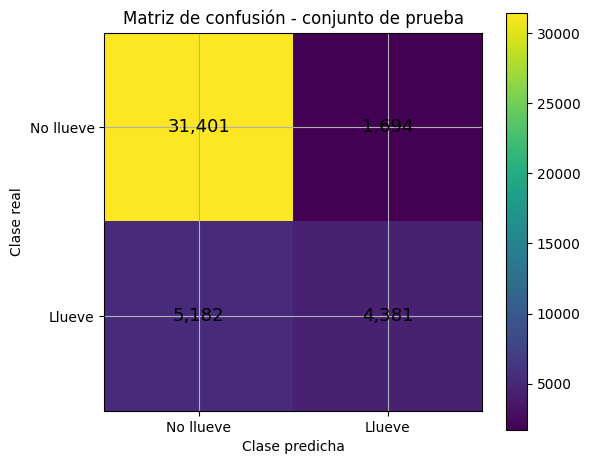

Verdaderos negativos (TN): 31,401
Falsos positivos (FP):     1,694
Falsos negativos (FN):     5,182
Verdaderos positivos (TP): 4,381


In [15]:
X_test_sm = sm.add_constant(X_test_processed, has_constant="add")
y_probability = logit_model.predict(X_test_sm)
THRESHOLD = 0.50
y_pred = (y_probability >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, f"{value:,}", ha="center", va="center", fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(["No llueve", "Llueve"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No llueve", "Llueve"])
ax.set_xlabel("Clase predicha"); ax.set_ylabel("Clase real")
ax.set_title("Matriz de confusión - conjunto de prueba")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("f2_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Verdaderos negativos (TN): {tn:,}")
print(f"Falsos positivos (FP):     {fp:,}")
print(f"Falsos negativos (FN):     {fn:,}")
print(f"Verdaderos positivos (TP): {tp:,}")

### 3.2 Métricas de clasificación

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
specificity = tn / (tn + fp)
roc_auc = roc_auc_score(y_test, y_probability)
pr_auc = average_precision_score(y_test, y_probability)
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())

metrics_table = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "Especificidad",
                "Balanced accuracy", "ROC-AUC", "PR-AUC", "Accuracy baseline mayoritaria"],
    "Valor": [accuracy, precision, recall, f1, specificity, balanced_accuracy,
              roc_auc, pr_auc, baseline_accuracy],
})
display(metrics_table.round(4))

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["No llueve", "Llueve"], digits=4))

,Métrica,Valor
0,Accuracy,0.8388
1,Precision,0.7212
2,Recall,0.4581
3,F1-score,0.5603
4,Especificidad,0.9488
5,Balanced accuracy,0.7035
6,ROC-AUC,0.8415
7,PR-AUC,0.6623
8,Accuracy baseline mayoritaria,0.7758


Reporte de clasificación:
              precision    recall  f1-score   support

   No llueve     0.8583    0.9488    0.9013     33095
      Llueve     0.7212    0.4581    0.5603      9563

    accuracy                         0.8388     42658
   macro avg     0.7898    0.7035    0.7308     42658
weighted avg     0.8276    0.8388    0.8249     42658



**Interpretación de métricas:**

**Accuracy:** el modelo clasifica correctamente cerca del 83.9% de las observaciones, pero
*cuidado*, con un desbalance de 22.4% de días con lluvia, un modelo que dijera "nunca llueve" ya
alcanzaría ~77.6%. La accuracy por sí sola no basta para juzgar el desempeño.

**Precision:** de los días que el modelo marca como lluviosos, el 72.1% efectivamente lo son.

**Recall:** el modelo detecta apenas el 45.8% de los días que realmente tendrán lluvia. En un
contexto donde omitir un día lluvioso es costoso (agricultura, eventos al aire libre), el recall
importa tanto o más que la precision, porque dejar pasar un día de lluvia real (falso negativo)
suele ser más costoso que generar una alerta de más (falso positivo).

**F1-score:** resume ese balance entre precision razonable y recall todavía moderado.

> **Para S3:** se evaluará ponderación de clase y ajuste del umbral de decisión para mejorar el
> recall de la clase minoritaria, y se compararán tres modelos en vez de uno solo.

### 3.3 Curva ROC y AUC

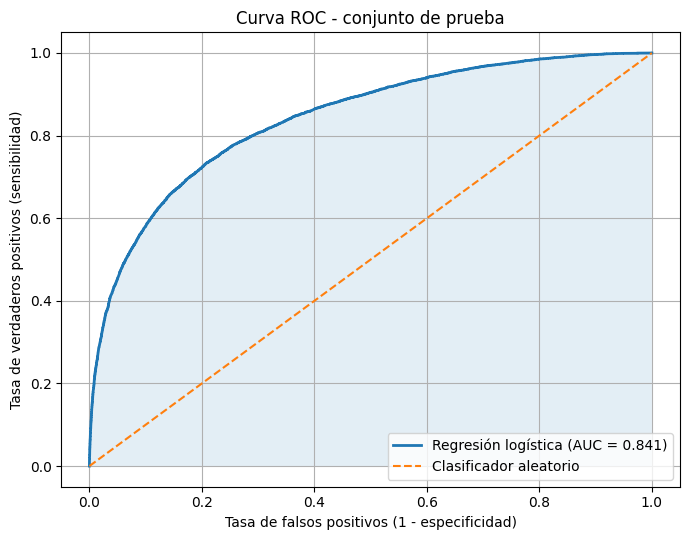

ROC-AUC = 0.8415
PR-AUC  = 0.6623 (métrica complementaria por desbalance)


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(fpr, tpr, linewidth=2, label=f"Regresión logística (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
ax.fill_between(fpr, tpr, alpha=0.12)
ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
ax.set_title("Curva ROC - conjunto de prueba")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("f2_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")
print(f"PR-AUC  = {pr_auc:.4f} (métrica complementaria por desbalance)")

**Interpretación del AUC:**

**Valor obtenido:** ≈0.842.

**Interpretación según la escala de referencia:**
- AUC = 0.5: no mejor que el azar
- AUC = 0.6-0.7: pobre
- AUC = 0.7-0.8: aceptable
- **AUC = 0.8-0.9: bueno** ← nuestro caso
- AUC > 0.9: excelente

**¿Qué significa en el contexto del problema?** Un AUC de ≈0.84 indica que, si se toman al azar un
día con lluvia y uno sin lluvia, el modelo asigna mayor probabilidad de riesgo al día lluvioso en
aproximadamente 84% de los pares comparados. Es una capacidad discriminante buena y, a diferencia
de la accuracy, no se deja engañar por el desbalance de clases.

> **Para S3:** se comparará el AUC de los tres modelos (dominio S1/S2, stepwise AIC/BIC y
> reducido) para elegir el modelo final con criterio.

## 4. Síntesis y reflexión

Responde las siguientes preguntas de reflexión:

### 1. Conexión con S1

**¿Cómo usamos los hallazgos de S1 para seleccionar variables?**

Partimos de la matriz de correlaciones de S1 e identificamos las variables más asociadas con
`RainTomorrow`: `Humidity3pm` (r≈0.45), `RainToday_bin` (r≈0.31), `Humidity9am` (r≈0.26),
`Pressure9am` (r≈-0.25) y `Rainfall` (r≈0.24). Descartamos `Sunshine` y `Evaporation` porque S1 ya
mostraba faltantes demasiado altos (≈48% y ≈43%), y evitamos usar `MaxTemp` junto a `Temp3pm` por
la colinealidad casi perfecta que S1 había detectado entre ambas (r≈0.985).

---

### 2. Conexión con S2

**¿Cómo usamos la validación de S2 para informar el modelo?**

S2 confirmó, mediante bootstrap BCa, que las cinco correlaciones elegidas eran **estables** (sus
intervalos de confianza al 95% no cruzaban cero). Eso dio la confianza estadística —no solo
intuición— para incluirlas. El análisis de robustez de S2 frente a la regla IQR también determinó
directamente el tratamiento de `Rainfall` (transformación `log1p` en vez de recorte de outliers) y
la decisión de no recortar `WindGustSpeed`, ya que sus valores extremos se interpretan como
ráfagas reales.

---

### 3. Evaluación del desempeño

**¿El modelo tiene buen desempeño? ¿Por qué sí o por qué no?**

Sí, con matices. El AUC (≈0.84) es bueno y muestra capacidad discriminante real. Sin embargo, con
umbral 0.5 y sin ponderación de clase, el recall es limitado (45.8%): se pierde más de la mitad de
los días con lluvia real. Para un problema donde omitir un día lluvioso tiene costo práctico, esa
es una debilidad relevante. La accuracy (83.9%) no debe leerse como éxito por sí sola, dado el
desbalance de 22.4% en la muestra.

---

### 4. Mejoras para S3

**¿Qué mejoraríamos en la Sumativa 3?**

Marca las que aplican:
- Probar otras variables**: incorporar `Humidity9am` y evaluar un modelo ampliado frente al
  reducido.
- Usar otra estrategia de imputación**: reemplazar la mediana por **imputación por
  regresión** y comparar contra eliminación e imputación simple.
- Ajustar múltiples modelos**: construir 3 modelos (dominio S1/S2, *stepwise* AIC/BIC y
  reducido) y elegir el mejor por métricas de prueba.
- Aplicar bootstrap a los coeficientes**: construir IC bootstrap del 95% para coeficientes y
  odds ratios, y verificar su estabilidad, replicando a nivel de modelo la técnica ya usada en S2
  para correlaciones simples.
- Ajustar el umbral de decisión**: evaluar ponderación de clase o un umbral distinto de 0.5
  para elevar el recall de la clase minoritaria.
- Otros: —

---

## Resumen Final

**En 3-5 oraciones, resumimos nuestra experiencia con esta formativa:**

Esta formativa nos permitió recorrer el flujo completo de modelamiento predictivo, desde preparar
los datos apoyándonos en S1/S2, ajustar un modelo logístico, interpretar odds ratios, diagnosticar
multicolinealidad y finalmente evaluar el desempeño con matriz de confusión, métricas y curva ROC.
El principal aprendizaje fue confirmar, con datos propios, por qué la accuracy engaña con clases
desbalanceadas y por qué el AUC y el recall son más informativos para este problema. Identificamos
con claridad las mejoras que incorporaremos en S3: tres modelos, imputación por regresión,
bootstrap de coeficientes y ajuste de umbral. Este notebook queda como base directa para la
Sumativa 3.

---
## Checklist de Entrega

Antes de entregar, verificamos:
- El notebook ejecuta sin errores de principio a fin.
- Documentamos los hallazgos de S1.
- Documentamos los hallazgos de S2.
- Justificamos la selección de variables basándonos en S1/S2.
- Ajustamos el modelo de regresión logística.
- Interpretamos los coeficientes y odds ratios.
- Calculamos VIF para multicolinealidad.
- Generamos la matriz de confusión.
- Calculamos métricas de desempeño (accuracy, precision, recall, F1).
- Generamos la curva ROC y calculamos el AUC.
- Respondimos las preguntas de reflexión.
- Fijamos la semilla (SEED=42) para reproducibilidad.

## Bibliografía

- Efron, B., & Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall/CRC.
- Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3.a ed.). Wiley.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*. Springer.
- Kaggle. (2017). *Rain in Australia / WeatherAUS* [Conjunto de datos].
- Maidana González, J. P. (2026). *Materiales del curso MCDI501*. Universidad Andrés Bello.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
- Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and Statistical Modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92-96.

In [18]:
final_summary = {
    "n_modeling": int(len(df)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "positive_rate_test": float(y_test.mean()),
    "threshold": THRESHOLD,
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "max_vif": float(max_vif),
    "model_converged": bool(logit_model.mle_retvals.get("converged", False)),
}
pd.Series(final_summary).to_frame("resultado")

,resultado
n_modeling,142193
n_train,99535
n_test,42658
positive_rate_test,0.2242
threshold,0.5000
accuracy,0.8388
precision,0.7212
recall,0.4581
f1,0.5603
roc_auc,0.8415
